In [587]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [588]:
df = pd.read_parquet("/Users/YGT/ist-airport-decision-support-system/data/silver/trajectories/trajectory_all.parquet")

In [589]:
df.head()

,hex,icao,date,trajectory_timestamp,point_timestamp,latitude,longitude,altitude_baro,ground_speed,track,baro_rate,nav_altitude_mcp,distance_km,on_ground
0,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:30:57+00:00,40.97,28.55,3075.00,232.00,101.90,NaN,3250.00,38.21,False
1,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:31:01+00:00,40.96,28.56,3075.00,229.50,101.30,-64.00,3250.00,38.10,False
2,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:33:50+00:00,41.03,28.71,3075.00,200.00,359.40,NaN,3250.00,27.07,False
3,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:34:03+00:00,41.05,28.71,3075.00,188.00,0.60,NaN,3250.00,25.74,False
4,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:34:07+00:00,41.05,28.71,3075.00,182.00,359.70,NaN,3250.00,25.37,False


In [590]:
df = df[["icao", "date", "trajectory_timestamp", "point_timestamp",	"latitude",	"longitude", "altitude_baro" ,"distance_km", "on_ground"]]

In [591]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31844737 entries, 0 to 31844736
Data columns (total 9 columns):
 #   Column                Dtype              
---  ------                -----              
 0   icao                  str                
 1   date                  str                
 2   trajectory_timestamp  datetime64[ms, UTC]
 3   point_timestamp       datetime64[ms, UTC]
 4   latitude              float32            
 5   longitude             float32            
 6   altitude_baro         float32            
 7   distance_km           float32            
 8   on_ground             bool               
dtypes: bool(1), datetime64[ms, UTC](2), float32(4), str(2)
memory usage: 1.9 GB


In [592]:
df.isna().sum()

icao                       0
date                       0
trajectory_timestamp       0
point_timestamp            0
latitude                   0
longitude                  0
altitude_baro           4332
distance_km                0
on_ground                  0
dtype: int64

## Duplicate Data Control

In [593]:
df = df.sort_values(["icao", "point_timestamp"]).reset_index(drop=True)

df = df.drop_duplicates(subset=["icao", "point_timestamp"], keep="last")

In [594]:
df.duplicated().sum()

np.int64(0)

# Removing Extreme Values

In [595]:
df["altitude_baro"].describe()

count   30641122.00
mean       16527.21
std        12521.07
min         -900.00
25%         5375.00
50%        12325.00
75%        27475.00
max        81700.00
Name: altitude_baro, dtype: float64

In [596]:
len(df)

30644684

In [597]:
df[
    (df['altitude_baro'] > -1000) &
    (df['altitude_baro'] < 50000)
].shape

(30641039, 9)

In [598]:
df = df[
    (df['altitude_baro'] > -1000) &
    (df['altitude_baro'] < 50000)
]

## Flight Segmentation

In [599]:
df["dt_s"] = (
    df.groupby("icao")["point_timestamp"]
      .diff()
      .dt.total_seconds()
)

In [600]:
df["dt_s"].describe()

count   30630624.00
mean        5027.08
std       147347.53
min            1.00
25%            3.00
50%            6.00
75%           13.00
max     27720008.00
Name: dt_s, dtype: float64

In [601]:
df = df.sort_values(["icao", "point_timestamp"]).reset_index(drop=True)

df["dt_s"] = df.groupby("icao")["point_timestamp"].diff().dt.total_seconds()

MAX_GAP_S = 900

df["episode_start"] = (df["dt_s"].fillna(0) > MAX_GAP_S) | df["icao"].ne(df["icao"].shift(1))

df["episode_id"] = df.groupby("icao")["episode_start"].cumsum()

df["flight_id"] = df["icao"].astype(str) + "_" + df["episode_id"].astype(str)

In [602]:
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)
flight_stats["dur_s"] = (flight_stats["t_end"] - flight_stats["t_start"]).dt.total_seconds()

print(flight_stats["n_points"].describe())
print(flight_stats["dur_s"].describe())

count   733337.00
mean        41.78
std         37.28
min          1.00
25%         14.00
50%         33.00
75%         60.00
max       7678.00
Name: n_points, dtype: float64
count   733337.00
mean       462.92
std        385.20
min          0.00
25%        154.00
50%        369.00
75%        721.00
max      22683.00
Name: dur_s, dtype: float64


## Flight Filtering

In [603]:
MAX_DUR_S = 7200  # 2 hour
valid_ids = flight_stats[
    (flight_stats["n_points"] >= 10) &
    (flight_stats["dur_s"] <= MAX_DUR_S)
].index

df = df[df["flight_id"].isin(valid_ids)]

In [604]:
print("n_points<10:", (flight_stats["n_points"] < 10).sum())
print("dur>7200s:", (flight_stats["dur_s"] > 7200).sum())
print("Final flight count:", df["flight_id"].nunique())

n_points<10: 124169
dur>7200s: 39
Final flight count: 609129


In [605]:
flight_stats.sort_values("dur_s", ascending=False).head(10)

,n_points,t_start,t_end,dur_s
flight_id,,,,
32b23b_5,7678,2025-04-23 10:42:56+00:00,2025-04-23 17:00:59+00:00,22683.00
32b405_14,1774,2026-01-21 11:28:43+00:00,2026-01-21 16:44:15+00:00,18932.00
001071_5,4989,2025-04-23 12:23:06+00:00,2025-04-23 17:21:51+00:00,17925.00
001069_2,417,2025-04-23 14:12:18+00:00,2025-04-23 19:03:11+00:00,17453.00
4b858e_1,365,2025-03-05 06:29:05+00:00,2025-03-05 11:06:03+00:00,16618.00
4b82da_1,466,2025-07-22 07:43:37+00:00,2025-07-22 12:05:52+00:00,15735.00
32b405_12,566,2025-12-30 09:40:42+00:00,2025-12-30 13:57:18+00:00,15396.00
32b408_6,2568,2025-05-07 17:08:18+00:00,2025-05-07 21:15:16+00:00,14818.00
151fa5_3,380,2025-03-12 16:59:17+00:00,2025-03-12 20:48:41+00:00,13764.00


In [606]:
df = df.sort_values(["flight_id","point_timestamp"]).reset_index(drop=True)

flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)

flight_stats["dur_s"] = (flight_stats["t_end"] - flight_stats["t_start"]).dt.total_seconds()

# drop data which have less point flight
MIN_POINTS = 10
valid_ids = flight_stats[flight_stats["n_points"] >= MIN_POINTS].index

df = df[df["flight_id"].isin(valid_ids)].copy()

print("kept flights:", df["flight_id"].nunique(), "rows:", len(df))

kept flights: 609129 rows: 30007948


## Altitude Spike Detection and Cleaning

In [607]:
df = df.sort_values(["flight_id", "point_timestamp"], kind="mergesort")

In [608]:
df["d_alt_ft"] = (
    df.groupby("flight_id")["altitude_baro"]
      .diff()
      .abs()
)

df["vs_fps"] = df["d_alt_ft"] / df["dt_s"]

In [609]:
df["vs_fps"].describe()

count   29398819.00
mean          17.72
std           22.02
min            0.00
25%            0.00
50%           16.44
75%           25.00
max        36675.00
Name: vs_fps, dtype: float64

In [610]:
(df["vs_fps"] > 150).sum()

np.int64(1195)

In [611]:
spike_mask = df["vs_fps"] > 150

spike_flights = df.loc[spike_mask, "flight_id"].nunique()
print("Spike içeren uçuş sayısı:", spike_flights)

Spike içeren uçuş sayısı: 946


In [612]:
spike_per_flight = (
    df.loc[spike_mask]
      .groupby("flight_id")
      .size()
      .sort_values(ascending=False)
)

spike_per_flight.head(10)

flight_id
68325a_2       48
68325a_1        8
4b9832_21       7
4ba995_1395     6
4a4d2c_10       6
490d09_2        6
49d039_1        5
4b94e7_14       5
4ba9ce_617      5
4bc8d3_273      5
dtype: int64

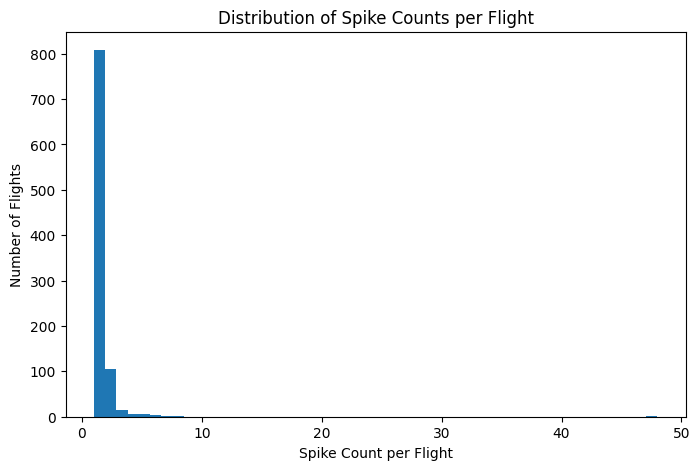

In [613]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(spike_per_flight, bins=50)
plt.xlabel("Spike Count per Flight")
plt.ylabel("Number of Flights")
plt.title("Distribution of Spike Counts per Flight")
plt.show()

In [614]:
flight_sizes = df.groupby("flight_id").size()

spike_ratio = spike_per_flight / flight_sizes

spike_ratio.sort_values(ascending=False).head(10)

flight_id
4b8533_636    0.20
4bb215_94     0.18
4baada_965    0.12
c074e9_10     0.11
68325a_1      0.11
4bb044_1275   0.11
0180a1_51     0.10
4bb868_14     0.10
4bc848_833    0.10
4baa70_1258   0.10
dtype: float64

In [615]:
SPIKE_VS_FPS = 150.0
spike_mask = df["vs_fps"].notna() & (df["vs_fps"] > SPIKE_VS_FPS)
df.loc[spike_mask, "altitude_baro"] = np.nan

## ENU Coordinate Transformation

In [616]:
import pymap3d as pm

In [617]:
LAT = 41.275278
LON = 28.751944
H0_M = 99.0

def add_enu_pymap3d(df, lat0=LAT, lon0=LON, h0_m=H0_M,
                    lat_col="latitude", lon_col="longitude", alt_ft_col="altitude_baro"):

    lat = df[lat_col].to_numpy(dtype=np.float64)
    lon = df[lon_col].to_numpy(dtype=np.float64)


    h_m = (df[alt_ft_col].to_numpy(dtype=np.float64) * 0.3048)

    # ENU (meters)
    e, n, u = pm.geodetic2enu(lat, lon, h_m, lat0, lon0, h0_m, deg=True)

    df = df.copy()
    df["e_m"] = e.astype(np.float32)
    df["n_m"] = n.astype(np.float32)
    df["u_m"] = u.astype(np.float32)
    return df


df = add_enu_pymap3d(df)

## 1 sec data resampling 

In [618]:
df.columns

Index(['icao', 'date', 'trajectory_timestamp', 'point_timestamp', 'latitude',
       'longitude', 'altitude_baro', 'distance_km', 'on_ground', 'dt_s',
       'episode_start', 'episode_id', 'flight_id', 'd_alt_ft', 'vs_fps', 'e_m',
       'n_m', 'u_m'],
      dtype='str')

In [624]:
print(df["dt_s"].describe(percentiles=[.5, .75, .9, .95, .99]))


count   29998704.00
mean        4264.20
std       133185.11
min            1.00
50%            6.00
75%           13.00
90%           20.00
95%           31.00
99%        25586.00
max     27720008.00
Name: dt_s, dtype: float64
